### 1-1. 공통

In [5]:
import sys
from pathlib import Path

# project 폴더를 sys.path에 추가
sys.path.append(str(Path().resolve().parent))

In [7]:
import matplotlib.pyplot as plt
from src.utils import set_matplotlib_font
set_matplotlib_font()

In [8]:
# 데이터 불러오기
import pandas as pd
pd.set_option('display.max_column', None)
pd.set_option('display.max_row', 100)

import seaborn as sns
sns.get_dataset_names()
titanic = sns.load_dataset('titanic')
display(titanic.head(2))


/Users/finn/miniconda3/envs/adp/lib/python3.7/site-packages/seaborn/utils.py:376: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 376 of the file /Users/finn/miniconda3/envs/adp/lib/python3.7/site-packages/seaborn/utils.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  gh_list = BeautifulSoup(http)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [9]:
# 데이터 기본 정보 확인
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.6+ KB




*   age, deck, embarked, embared_town은 결측치가 있는 것으로 확인
*   deck는 결측치가 과반수 이상이기 때문에 특성을 삭제
*   만약 id값이 들어있는 경우 이 경우도 수치적으로 의미없는 데이터이므로 삭제
*   age, embared의 결측치는 보간한다.
*   변수 별 데이터 타입을 맞춰준다. (질적변수 / 양적 변수)



In [10]:
del_feat = ['deck']
titanic = titanic.drop(del_feat, axis=1)

qual = ['survived', 'pclass', 'sex', 'class','embarked', 'embark_town', 'who', 'adult_male', 'alive', 'alone']
quan = ['age', 'sibsp', 'parch', 'fare']

for col in qual : titanic[col] = titanic[col].astype('category')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    category
 1   pclass       891 non-null    category
 2   sex          891 non-null    category
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    category
 10  adult_male   891 non-null    category
 11  embark_town  889 non-null    category
 12  alive        891 non-null    category
 13  alone        891 non-null    category
dtypes: category(10), float64(2), int64(2)
memory usage: 37.6 KB


In [11]:
# 기술 통계 - 양적 변수
titanic.describe(include=['float64', 'int64'])

,age,sibsp,parch,fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [12]:
# 기술통계 - 질적변수
titanic.describe(include=['category'])

,survived,pclass,sex,embarked,class,who,adult_male,embark_town,alive,alone
count,891,891,891,889,891,891,891,889,891,891
unique,2,3,2,3,3,3,2,3,2,2
top,0,3,male,S,Third,man,True,Southampton,no,True
freq,549,491,577,644,491,537,537,644,549,537


### 1-2. 질적변수

In [13]:
# 도수 분포표와 상대도수 분포표
freq = pd.DataFrame()
freq['도수'] = titanic.survived.value_counts()
freq['상대도수'] = titanic.survived.value_counts(normalize=True)

display(freq)

,도수,상대도수
0,549,0.616162
1,342,0.383838


In [14]:
# 스피어만 순위상관계수 및 켄달의 타우
from scipy.stats import spearmanr, kendalltau

corr, p = spearmanr(titanic.survived, titanic.pclass)
display('스피어만 상관계수는 {:.3f}, p-value는 {:.3f}'.format(corr,p))

corr2, p2 = kendalltau(titanic.survived, titanic.pclass)
display('켄달타우 상관계수는 {:.3f}, p-value는 {:.3f}'.format(corr2,p2))

'스피어만 상관계수는 -0.340, p-value는 0.000'

'켄달타우 상관계수는 -0.324, p-value는 0.000'



*   **<Linux 한글 폰트 설치 후 작업>**
*   apt update
*   apt install -y language-pack-ko fonts-nanum-* fontconfig
*   fc-cache -f -v
*   rm -rf ~/.cache/matplotlib
*   fc-list :lang=ko

</br>

*   **<그외 OS 기본 한글 폰트>**
*   Windows : Malgun Gothic
*   Mac : AppleGothic

</br>
*   그외, 폰트에 대한 자세한 내용 ㅣ https://corazzon.github.io/matplotlib_font_s

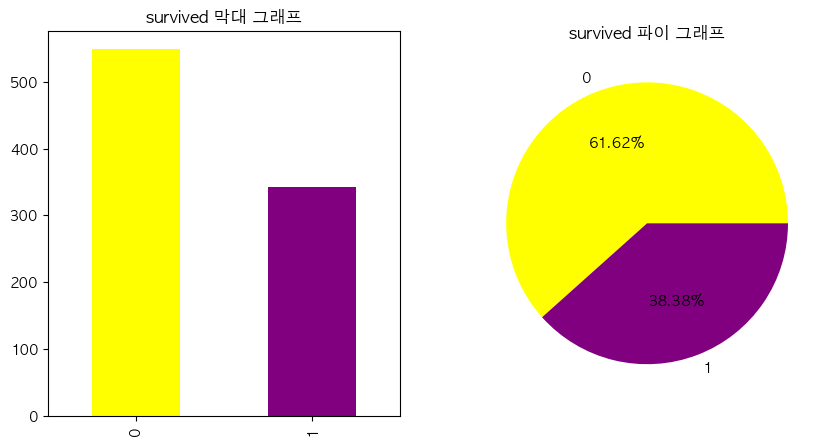

In [15]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].set_title('survived 막대 그래프')
freq['도수'].plot.bar(ax=ax[0], color=['yellow', 'purple'])

ax[1].set_title('survived 파이 그래프')
ax[1].pie(freq.도수.values, labels=freq.도수.index, autopct="%.2f%%", colors=['yellow', 'purple'])
plt.show()

### 1-3. 양적변수

In [41]:
# 도수 분포표와 상대도수 분포표
import pandas as pd

result = pd.cut(titanic.age, bins=5)
freq = result.value_counts().to_frame().reset_index().sort_values('age')
display(freq)

freq.rename(columns={'age':'구간', 'count':'도수'}, inplace=True)
freq['상대도수'] = freq.도수 / freq.도수.sum()
display(freq)

,index,age
4,"(64.084, 80.0]",11
3,"(48.168, 64.084]",69
2,"(0.34, 16.336]",100
1,"(32.252, 48.168]",188
0,"(16.336, 32.252]",346


AttributeError: 'DataFrame' object has no attribute '도수'

In [22]:
# 도수 분포표와 상대도수 분포표
import pandas as pd

result = pd.cut(titanic.age, bins=[0,20,40,60,float('inf')], right=False)
freq = result.value_counts().to_frame().reset_index().sort_values('age')
display(freq)
freq.rename(columns={'index':'구간', 'age':'도수'}, inplace=True)

freq['상대도수'] = freq.도수 / freq.도수.sum()
display(freq)

,index,age
3,"[60.0, inf)",26
2,"[40.0, 60.0)",137
1,"[0.0, 20.0)",164
0,"[20.0, 40.0)",387


,구간,도수,상대도수
3,"[60.0, inf)",26,0.036415
2,"[40.0, 60.0)",137,0.191877
1,"[0.0, 20.0)",164,0.229692
0,"[20.0, 40.0)",387,0.542017


In [23]:
# 계산적 대푯값
from scipy.stats.mstats import gmean, hmean, tmean
import numpy as np

example=[1,2,3,4,5,10]
print('산술평균 : {:.3f}'.format(np.mean(example)))
print('기하평균 : {:.3f}'.format(gmean(example)))
print('조화평균 : {:.3f}'.format(hmean(example)))
print('절사평균 : {:.3f}'.format(tmean(example, (1,5))))

# 평방평균 : sqrt(mean(element wise squre))
qm = np.sqrt(np.mean(np.square(example)))
print('평방평균 : {:.3f}'.format(qm))

산술평균 : 4.167
기하평균 : 3.260
조화평균 : 2.517
절사평균 : 3.000
평방평균 : 5.083


In [24]:
# 위치적 대푯값
print('중위수: ', titanic.fare.median())
print('최빈값: ', titanic.fare.mode()[0])
print('1사분위수: ', titanic.fare.quantile(q=0.25))
print('2사분위수: ', titanic.fare.quantile(q=0.5))
print('3사분위수: ', titanic.fare.quantile(q=0.75))
print('백분위수 (50%): ', titanic.fare.quantile(q=0.50))
print('백분위수 (75%): ', titanic.fare.quantile(q=0.75))

중위수:  14.4542
최빈값:  8.05
1사분위수:  7.9104
2사분위수:  14.4542
3사분위수:  31.0
백분위수 (50%):  14.4542
백분위수 (75%):  31.0


In [25]:
# 절대적 산포도
"""
범위 = 최대 - 최소
사분위범위(IQR) = 3사 분위수(75% 백분위) - 1사 분위수(25% 백분위수)
평균편차 = 편차 절댓값의 산술평균
사분편차 = 사분위범위/2
분산 : 편차 제곱의 산술평균
표준편차 = 분산의 양의 제곱근
"""

print('범위: ', titanic.fare.max() - titanic.fare.min())
iqr = titanic.fare.quantile(q=0.75) - titanic.fare.quantile(q=0.25)
print('사분위범위: %.2f' %(iqr), "\n")

md = np.mean(np.abs(titanic.fare - titanic.fare.mean()))
md2 = iqr/1.349
print('평균편차: %.2f' %(md))
print('사분편차: %.2f' %(md2), "\n")

print('모분산: %.2f' %(titanic.fare.var(ddof=0)))
print('표본분산: %.2f' %(titanic.fare.var(ddof=1)))

print('모표준편차: %.2f' %(titanic.fare.std(ddof=0)))
print('표본표준편차: %.2f' %(titanic.fare.std(ddof=1)))


범위:  512.3292
사분위범위: 23.09 

평균편차: 28.16
사분편차: 17.12 

모분산: 2466.67
표본분산: 2469.44
모표준편차: 49.67
표본표준편차: 49.69


In [26]:
# 상대적 산포도
"""
사분위편차계수(CQD) = 사분편차/중앙값
평균편차계수(CMD) = 평균편차/산술평균
변동계수(CV) = 표준편차/산술평균
"""
print('사분위편차계수: %.2f' %(iqr/titanic.fare.median()))
print('평균편차계수: %.2f' %(md/titanic.fare.mean()))
print('모집단 변동계수: %.2f' %(titanic.fare.std(ddof=0)/titanic.fare.mean()))
print('표본집단 변동계수: %.2f' %(titanic.fare.std(ddof=1)/titanic.fare.mean()))


사분위편차계수: 1.60
평균편차계수: 0.87
모집단 변동계수: 1.54
표본집단 변동계수: 1.54


In [27]:
# 왜도, 첨도
# pandas
print("왜도: %.3f" %(titanic.fare.skew()))
print("첨도: %.3f" %(titanic.fare.kurt()))

# sicpy
from scipy.stats import skew, kurtosis
ssF = skew(titanic.fare, bias=False)
skF = kurtosis(titanic.fare, bias=False)
ssT = skew(titanic.fare, bias=True)
skT = kurtosis(titanic.fare, bias=True)

print("왜도(비편향): %.3f" %(ssF))
print("첨도(비편향): %.3f" %(skF))
print("왜도(편향): %.3f" %(ssT))
print("첨도(편향): %.3f" %(skT))

왜도: 4.787
첨도: 33.398
왜도(비편향): 4.787
첨도(비편향): 33.398
왜도(편향): 4.779
첨도(편향): 33.204


In [28]:
# 양적변수 탐색 시각화 - 줄기잎그림(자료가 적을 때)
def custom_stem_leaf_plot(data, scale_factor=1, title="Stem-and-Leaf Plot"): # scale_factor는 줄기를 나누는 단위
    data = data.dropna().astype(int) # NaN 제거 및 정수형 변환

    if data.empty:
        print("데이터가 비어 있습니다.")
        return

    # 스템(줄기)과 리프(잎) 생성
    stems = {}
    for x in data:
        stem = int(x // scale_factor) # 줄기 계산
        leaf = int(x % scale_factor)   # 잎 계산
        if stem not in stems:
            stems[stem] = []
        stems[stem].append(leaf)

    # 줄기를 정렬하고 잎을 정렬
    sorted_stems = sorted(stems.keys())

    print(f"\n--- {title} ---")
    print(f"단위: {scale_factor}\n")

    for stem in sorted_stems:
        leaves = sorted(stems[stem])
        # 각 잎을 문자열로 변환하고 공백으로 구분하여 출력
        print(f"{stem * scale_factor: <5d} | {' '.join(map(str, leaves))}")

# age 컬럼의 줄기잎그림 생성
# age는 일반적으로 1의 자리까지 표시하므로 scale_factor를 10으로 설정하여 10의 자리를 줄기로, 1의 자리를 잎으로 표시합니다.
custom_stem_leaf_plot(titanic.age, scale_factor=10, title="Age Stem-and-Leaf Plot")

# 예시: 만약 age가 0-9까지 숫자가 많으면 scale_factor=1로 설정할 수도 있습니다.
# custom_stem_leaf_plot(titanic.age, scale_factor=1, title="Age Stem-and-Leaf Plot (Unit 1)")


--- Age Stem-and-Leaf Plot ---
단위: 10

0     | 0 0 0 0 0 0 0 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 6 6 6 7 7 7 8 8 8 8 9 9 9 9 9 9 9 9
10    | 0 0 1 1 1 1 2 3 3 4 4 4 4 4 4 4 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
20    | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9
30    | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 

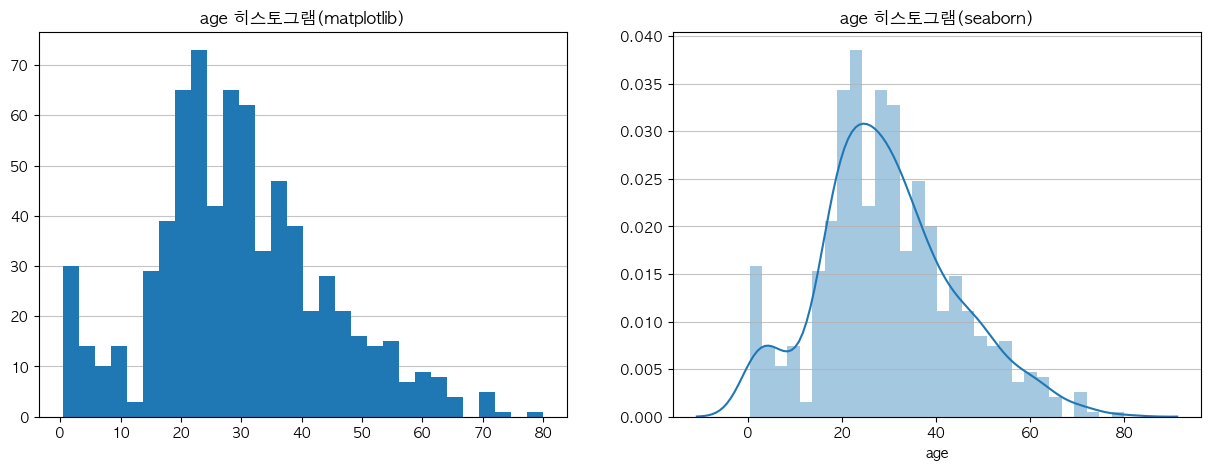

In [39]:
# 양적변수 탐색 시각화 - 히스토그램(자료가 많을 때)
import seaborn as sns
import plotly.express as px # https://kimhongsi.tistory.com/entry/Python-px-Plotly-Express-%EB%9E%80-%EC%82%AC%EC%9A%A9%EB%B0%A9%EB%B2%95
import plotly.graph_objects as go

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].hist(titanic.age, bins=30, zorder=2)
ax[0].set_title('age 히스토그램(matplotlib)')
ax[0].grid(axis='y', alpha=0.75, zorder=1)

sns.distplot(titanic.age, bins=30, kde=True, ax=ax[1])
ax[1].set_title('age 히스토그램(seaborn)')
ax[1].grid(axis='y', alpha=0.75, zorder=1)
plt.show()

KeyError: 'count'

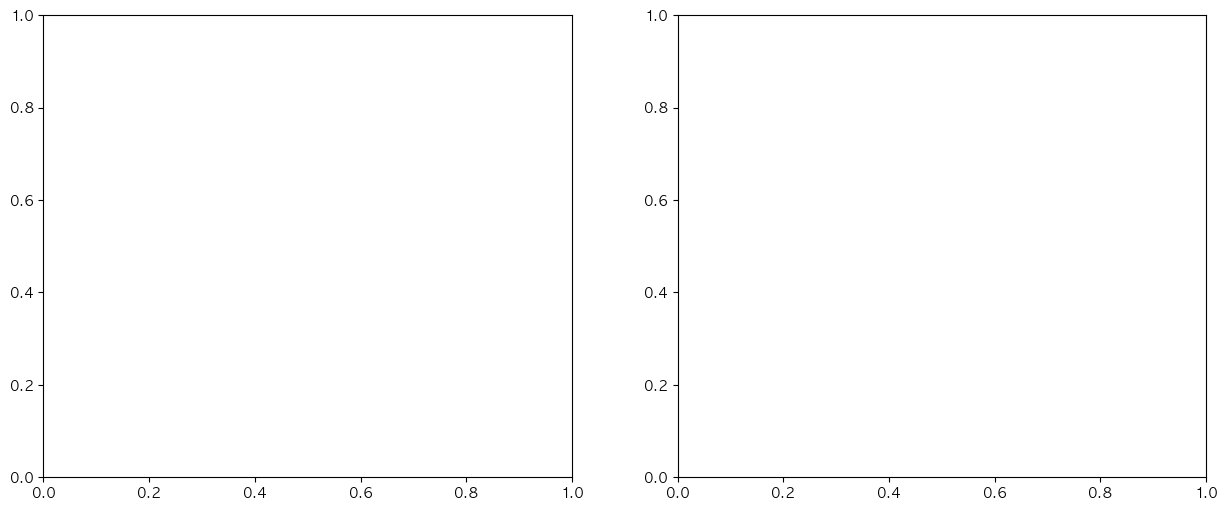

In [40]:
# 양적변수 탐색 시각화 - 누적히스토그램(자료가 많을 때)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

result = pd.cut(titanic.age.dropna(), bins=[i for i in range(0, 100, 10)]).to_frame().value_counts().reset_index().rename(columns={'age':'level'}).sort_values(by="level")
result.insert(1, 'grade', result['level'].apply(lambda x: x.right )) # np.median([x.left, x.right]
result['ccount'] = result['count'].cumsum()
display(result)

axes[0].plot(result.grade, result.ccount, marker='o', zorder=2) #Ogive 그래프
axes[0].hist(titanic.age, bins=30, cumulative=True, edgecolor='black', linewidth=1, zorder=1) # https://wikidocs.net/92112
axes[0].set_title('comulative frequency - matplotlib')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.75, zorder=1)

sns.distplot(titanic['age'].dropna(), bins=30, cumulative=True, stat='count', ax=axes[1], color='red', kde=True)
axes[1].set_title('comulative frequency - seaborn')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Cumulative Count')
axes[1].grid(axis='y', alpha=0.75, zorder=1)

plt.tight_layout()
plt.show()

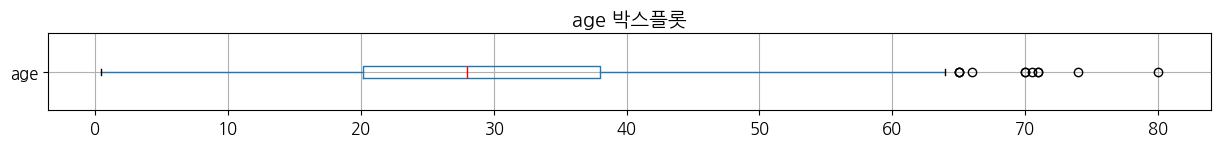

In [210]:
# 양적변수 탐색 시각화 - 박스플롯
# vert= 수평/수직, medianprops={'color':'색상'}

titanic.age.to_frame().boxplot(vert=False, medianprops={'color':'red'}, figsize=(15,1))
plt.title('age 박스플롯')
plt.show()

Text(0, 0.5, 'Ys')

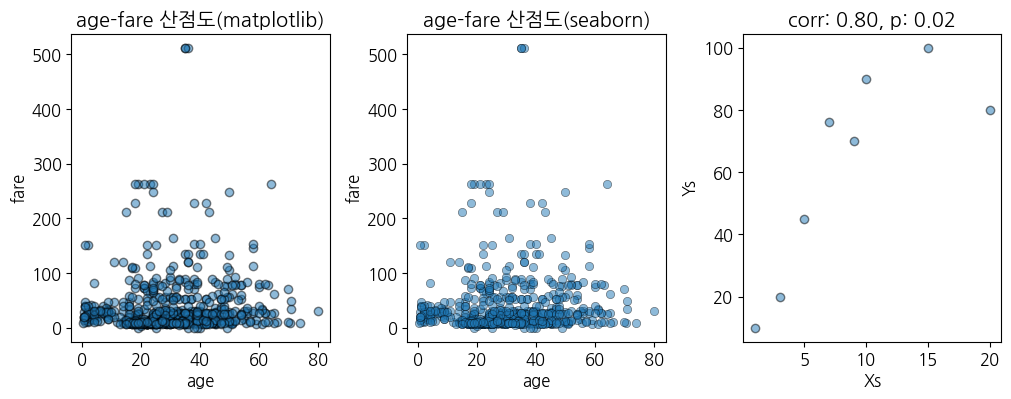

In [222]:
# 양적변수 탐색 시각화 - 산점도
fig, ax = plt.subplots(1,3, figsize=(12,4)) ; plt.subplots_adjust(wspace=0.3)
ax[0].scatter(titanic.age, titanic.fare, edgecolors='black', alpha=0.5, zorder=2)
ax[0].set_title('age-fare 산점도(matplotlib)')
ax[0].set_xlabel('age')
ax[0].set_ylabel('fare')

sns.scatterplot(x='age', y='fare', data=titanic, ax=ax[1], edgecolor='black', alpha=0.5, zorder=2)
ax[1].set_title('age-fare 산점도(seaborn)')

from scipy.stats import pearsonr # Corrected import statement
Xs=[1,3,5,7,9,15,20,10]
Ys=[10,20,45,76,70,100,80,90]
ax[2].scatter(Xs, Ys, edgecolors='black', alpha=0.5, zorder=2)
ax[2].set_title('corr: %.2f, p: %.2f' %(pearsonr(Xs,Ys)))
ax[2].set_xlabel('Xs')
ax[2].set_ylabel('Ys') # Completed the line